# Task 2 & 3 — Rejection ABC & Summary Statistic Experiments

Workflow:
1. **Generate** prior samples + raw simulations once, save to disk
2. **Load** observed data & saved simulations
3. **Define** modular summary statistics — swap `ACTIVE_SET` to experiment
4. **Reduce** dimensionality (PCA / UMAP) to visualise how well summaries separate parameters
5. **Run** rejection ABC and inspect the approximate posterior

In [1]:
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "scripts"))

## 1. Generate Prior Simulations

Runs `simulate_prior.py` once and saves `data/prior_simulations.npz`.  
Re-run is skipped automatically if the file already exists — delete it to regenerate.

In [4]:
# ── Config ────────────────────────────────────────────────────────────────────
M    = 10_000   # number of prior draws
R    = 40       # replicates per draw (match observed)
SEED = 0
OUT  = ROOT / "data" / "prior_simulations.npz"

# ── Run ───────────────────────────────────────────────────────────────────────
if OUT.exists():
    print(f"Found {OUT} — skipping simulation.")
    print("Delete the file and re-run this cell to regenerate.")
else:
    result = subprocess.run(
        [
            sys.executable,
            str(ROOT / "scripts" / "simulate_prior.py"),
            "--M",    str(M),
            "--R",    str(R),
            "--seed", str(SEED),
            "--out",  str(OUT),
        ],
        capture_output=True,
        text=True,
    )
    print(result.stdout)
    if result.returncode != 0:
        print("STDERR:", result.stderr)

Found /Users/floriandreyer/Library/Mobile Documents/com~apple~CloudDocs/Studium/B.Sc. Data Science/Singapur/Simulation/SimulationProject/data/prior_simulations.npz — skipping simulation.
Delete the file and re-run this cell to regenerate.


## 2. Load Data

Observed: inf=(40, 201), rew=(40, 201), deg=(40, 31)


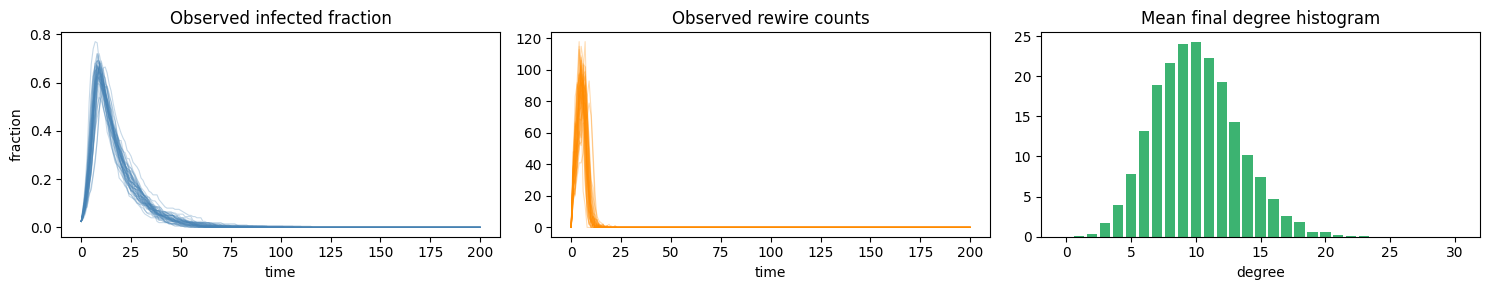

In [5]:
def load_observed(data_dir: Path):
    """Return obs_inf (R,T+1), obs_rew (R,T+1), obs_deg (R,31) as float arrays."""
    inf_df = pd.read_csv(data_dir / "infected_timeseries.csv")
    rew_df = pd.read_csv(data_dir / "rewiring_timeseries.csv")
    deg_df = pd.read_csv(data_dir / "final_degree_histograms.csv")

    obs_inf = (
        inf_df.pivot(index="replicate_id", columns="time", values="infected_fraction")
        .sort_index().values.astype(float)
    )
    obs_rew = (
        rew_df.pivot(index="replicate_id", columns="time", values="rewire_count")
        .sort_index().values.astype(float)
    )
    obs_deg = (
        deg_df.pivot(index="replicate_id", columns="degree", values="count")
        .sort_index().values.astype(float)
    )
    return obs_inf, obs_rew, obs_deg


obs_inf, obs_rew, obs_deg = load_observed(ROOT / "data")
print(f"Observed: inf={obs_inf.shape}, rew={obs_rew.shape}, deg={obs_deg.shape}")

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
axes[0].plot(obs_inf.T, alpha=0.3, color="steelblue", lw=0.8)
axes[0].set(title="Observed infected fraction", xlabel="time", ylabel="fraction")
axes[1].plot(obs_rew.T, alpha=0.3, color="darkorange", lw=0.8)
axes[1].set(title="Observed rewire counts", xlabel="time")
axes[2].bar(np.arange(31), obs_deg.mean(axis=0), color="mediumseagreen")
axes[2].set(title="Mean final degree histogram", xlabel="degree")
plt.tight_layout()

In [6]:
raw = np.load(OUT)
thetas    = raw["thetas"]                            # (M, 3)  [beta, gamma, rho]
sim_inf   = raw["infected_fractions"]                # (M, R, 201)
sim_rew   = raw["rewire_counts"].astype(float)       # (M, R, 201)
sim_deg   = raw["degree_histograms"].astype(float)   # (M, R, 31)
M_loaded, R_loaded = sim_inf.shape[:2]
print(f"Loaded {M_loaded:,} draws × {R_loaded} replicates")
print(f"  thetas {thetas.shape} | inf {sim_inf.shape} | rew {sim_rew.shape} | deg {sim_deg.shape}")

Loaded 10,000 draws × 40 replicates
  thetas (10000, 3) | inf (10000, 40, 201) | rew (10000, 40, 201) | deg (10000, 40, 31)


## 3. Summary Statistics

Each feature function takes `(inf, rew, deg)` arrays of shape `(M, R, …)` and returns `(M, k)`.  
For observed data (shape `(R, …)`) we temporarily add a batch dimension.

**To experiment with different summary sets, change `ACTIVE_SET` below.**

In [7]:
# ── Degree distribution helpers ───────────────────────────────────────────────
DEGREES = np.arange(31, dtype=float)

def _degree_mean(deg):   # (M, R, 31) → (M, 1)
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    return ((deg * DEGREES).sum(axis=2, keepdims=True) / total).mean(axis=1)

def _degree_std(deg):    # (M, R, 31) → (M, 1)
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    mu  = (deg * DEGREES).sum(axis=2) / total.squeeze(2)
    mu2 = (deg * DEGREES**2).sum(axis=2) / total.squeeze(2)
    return np.sqrt((mu2 - mu**2).clip(min=0)).mean(axis=1, keepdims=True)

# ── Feature catalogue ─────────────────────────────────────────────────────────
# Each entry: (name, function(inf, rew, deg) → (M, k))
# inf: (M, R, T+1)  rew: (M, R, T+1)  deg: (M, R, 31)

FEATURE_FUNCS = {
    # --- infection time-series ---
    "peak_inf":          lambda i, w, d: np.max(i, axis=2).mean(axis=1, keepdims=True),
    "time_to_peak_inf":  lambda i, w, d: np.argmax(i, axis=2).astype(float).mean(axis=1, keepdims=True),
    "final_inf":         lambda i, w, d: i[:, :, -1].mean(axis=1, keepdims=True),
    "total_inf":         lambda i, w, d: i.sum(axis=2).mean(axis=1, keepdims=True),
    "inf_ts20":          lambda i, w, d: i[:, :, np.linspace(0, i.shape[2]-1, 20, dtype=int)].mean(axis=1),  # (M, 20)
    "std_peak_inf":      lambda i, w, d: np.max(i, axis=2).std(axis=1, keepdims=True),   # cross-replicate variance
    # --- rewiring ---
    "total_rew":         lambda i, w, d: w.sum(axis=2).mean(axis=1, keepdims=True),
    "peak_rew":          lambda i, w, d: np.max(w, axis=2).mean(axis=1, keepdims=True),
    "time_to_peak_rew":  lambda i, w, d: np.argmax(w, axis=2).astype(float).mean(axis=1, keepdims=True),
    "rew_ts20":          lambda i, w, d: w[:, :, np.linspace(0, w.shape[2]-1, 20, dtype=int)].mean(axis=1),  # (M, 20)
    # --- degree histogram ---
    "mean_degree":       lambda i, w, d: _degree_mean(d),
    "std_degree":        lambda i, w, d: _degree_std(d),
    "isolated_frac":     lambda i, w, d: (d[:, :, 0] / d.sum(axis=2).clip(min=1)).mean(axis=1, keepdims=True),
    "high_degree_frac":  lambda i, w, d: (d[:, :, 20:].sum(axis=2) / d.sum(axis=2).clip(min=1)).mean(axis=1, keepdims=True),
}

# ── Summary sets to compare ───────────────────────────────────────────────────
SUMMARY_SETS = {
    "infection_only": [
        "peak_inf", "time_to_peak_inf", "final_inf", "total_inf",
    ],
    "infection_ts": [
        "inf_ts20", "std_peak_inf",
    ],
    "rewiring_only": [
        "total_rew", "peak_rew", "time_to_peak_rew",
    ],
    "degree_only": [
        "mean_degree", "std_degree", "isolated_frac", "high_degree_frac",
    ],
    "all_scalar": [
        "peak_inf", "time_to_peak_inf", "final_inf", "total_inf", "std_peak_inf",
        "total_rew", "peak_rew", "time_to_peak_rew",
        "mean_degree", "std_degree", "isolated_frac", "high_degree_frac",
    ],
    "all": [
        "inf_ts20", "std_peak_inf",
        "rew_ts20",
        "mean_degree", "std_degree", "isolated_frac", "high_degree_frac",
    ],
}

# ── Active set (change this to experiment) ────────────────────────────────────
ACTIVE_SET = "all"

print(f"Active set: '{ACTIVE_SET}' → features: {SUMMARY_SETS[ACTIVE_SET]}")

Active set: 'all' → features: ['inf_ts20', 'std_peak_inf', 'rew_ts20', 'mean_degree', 'std_degree', 'isolated_frac', 'high_degree_frac']


In [8]:
def compute_summaries(inf, rew, deg, feature_set=ACTIVE_SET):
    """Compute summary statistics for a batch or single observation.

    Parameters
    ----------
    inf : (M, R, T+1) or (R, T+1)
    rew : (M, R, T+1) or (R, T+1)
    deg : (M, R, 31)  or (R, 31)

    Returns
    -------
    (M, n_features) or (n_features,) for a single observation
    """
    squeeze = inf.ndim == 2
    if squeeze:
        inf, rew, deg = inf[np.newaxis], rew[np.newaxis], deg[np.newaxis]
    rew = rew.astype(float)
    deg = deg.astype(float)

    parts = []
    for name in SUMMARY_SETS[feature_set]:
        feat = FEATURE_FUNCS[name](inf, rew, deg)   # (M,) or (M, k)
        if feat.ndim == 1:
            feat = feat[:, np.newaxis]
        parts.append(feat)

    result = np.concatenate(parts, axis=1)           # (M, n_features)
    return result[0] if squeeze else result


# ── Compute ───────────────────────────────────────────────────────────────────
sim_stats = compute_summaries(sim_inf, sim_rew, sim_deg)    # (M, n_features)
obs_stats = compute_summaries(obs_inf, obs_rew, obs_deg)    # (n_features,)

print(f"Simulated summary matrix : {sim_stats.shape}")
print(f"Observed summary vector  : {obs_stats.shape}")

Simulated summary matrix : (10000, 45)
Observed summary vector  : (45,)


## 4. Dimensionality Reduction

Fit on simulated summaries, project observed point into the same space.  
Colour by each parameter to see which summaries separate which parameter.

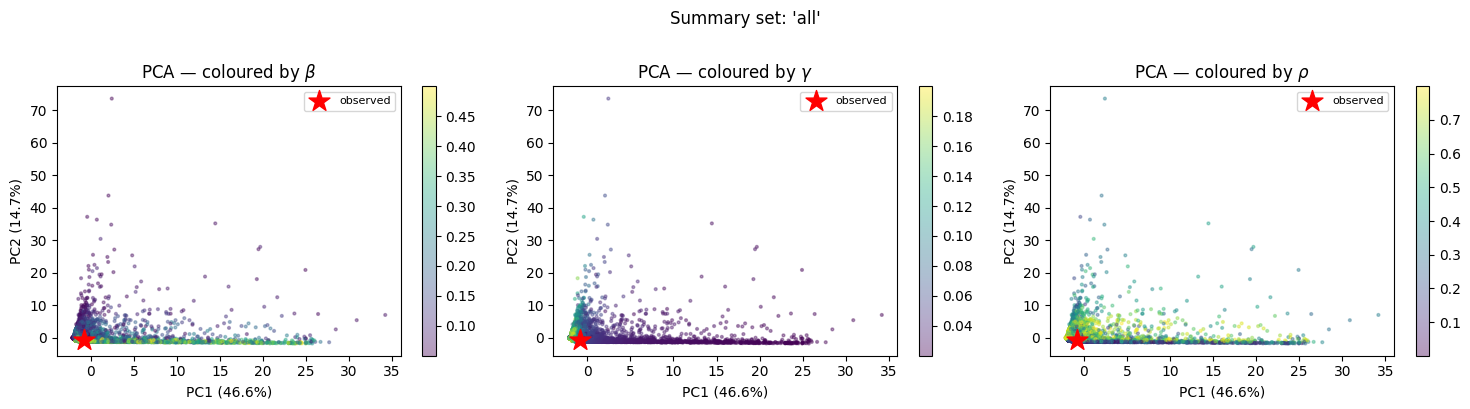

In [9]:
# ── PCA ───────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
sim_scaled = scaler.fit_transform(sim_stats)
obs_scaled = scaler.transform(obs_stats[np.newaxis])

pca = PCA(n_components=2)
sim_pc = pca.fit_transform(sim_scaled)      # (M, 2)
obs_pc = pca.transform(obs_scaled)[0]       # (2,)

param_names = [r"$\beta$", r"$\gamma$", r"$\rho$"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, j, name in zip(axes, range(3), param_names):
    sc = ax.scatter(sim_pc[:, 0], sim_pc[:, 1],
                    c=thetas[:, j], cmap="viridis", s=4, alpha=0.4, rasterized=True)
    ax.scatter(*obs_pc, marker="*", s=250, c="red", zorder=5, label="observed")
    fig.colorbar(sc, ax=ax)
    ax.set(title=f"PCA — coloured by {name}",
           xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
           ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.legend(fontsize=8)
plt.suptitle(f"Summary set: '{ACTIVE_SET}'", y=1.01)
plt.tight_layout()

In [10]:
# ── UMAP (optional — install with: pip install umap-learn) ────────────────────
try:
    from umap import UMAP

    # Sub-sample for speed if M is large
    N_UMAP = min(5_000, len(sim_scaled))
    idx = np.random.default_rng(42).choice(len(sim_scaled), N_UMAP, replace=False)

    reducer = UMAP(n_components=2, random_state=42, verbose=False)
    sim_umap = reducer.fit_transform(sim_scaled[idx])
    obs_umap = reducer.transform(obs_scaled)[0]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, j, name in zip(axes, range(3), param_names):
        sc = ax.scatter(sim_umap[:, 0], sim_umap[:, 1],
                        c=thetas[idx, j], cmap="viridis", s=4, alpha=0.4, rasterized=True)
        ax.scatter(*obs_umap, marker="*", s=250, c="red", zorder=5, label="observed")
        fig.colorbar(sc, ax=ax)
        ax.set(title=f"UMAP — coloured by {name}", xlabel="UMAP-1", ylabel="UMAP-2")
        ax.legend(fontsize=8)
    plt.suptitle(f"Summary set: '{ACTIVE_SET}'  (N={N_UMAP:,})", y=1.01)
    plt.tight_layout()

except ImportError:
    print("umap-learn not installed.  Run: pip install umap-learn")

umap-learn not installed.  Run: pip install umap-learn


## 5. Rejection ABC

Distance: standardised Euclidean (divide each feature by its std across all simulations).  
Tolerance: accept the top `QUANTILE` fraction by distance.

In [11]:
# ── Config ────────────────────────────────────────────────────────────────────
QUANTILE = 0.01   # accept top 1 % closest draws

# ── Normalise & compute distances ─────────────────────────────────────────────
feat_std = sim_stats.std(axis=0).clip(min=1e-10)   # avoid div-by-zero
sim_norm = sim_stats / feat_std
obs_norm = obs_stats / feat_std

distances = np.linalg.norm(sim_norm - obs_norm, axis=1)   # (M,)

epsilon = np.quantile(distances, QUANTILE)
accepted = thetas[distances <= epsilon]
print(f"Tolerance ε = {epsilon:.4f}  |  Accepted {len(accepted):,} / {len(distances):,} "
      f"({len(accepted)/len(distances):.1%})")

Tolerance ε = 1.0596  |  Accepted 100 / 10,000 (1.0%)


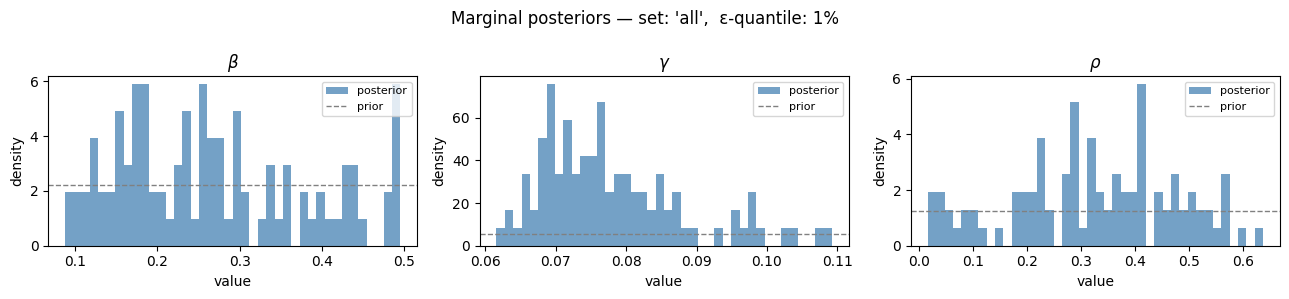

In [12]:
# ── Marginal posteriors ───────────────────────────────────────────────────────
PRIOR_LOW  = np.array([0.05, 0.02, 0.0])
PRIOR_HIGH = np.array([0.50, 0.20, 0.8])

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, j, name in zip(axes, range(3), param_names):
    ax.hist(accepted[:, j], bins=40, density=True, color="steelblue", alpha=0.75, label="posterior")
    ax.axhline(1 / (PRIOR_HIGH[j] - PRIOR_LOW[j]), color="grey", ls="--", lw=1, label="prior")
    ax.set(title=name, xlabel="value", ylabel="density")
    ax.legend(fontsize=8)
plt.suptitle(f"Marginal posteriors — set: '{ACTIVE_SET}',  ε-quantile: {QUANTILE:.0%}")
plt.tight_layout()

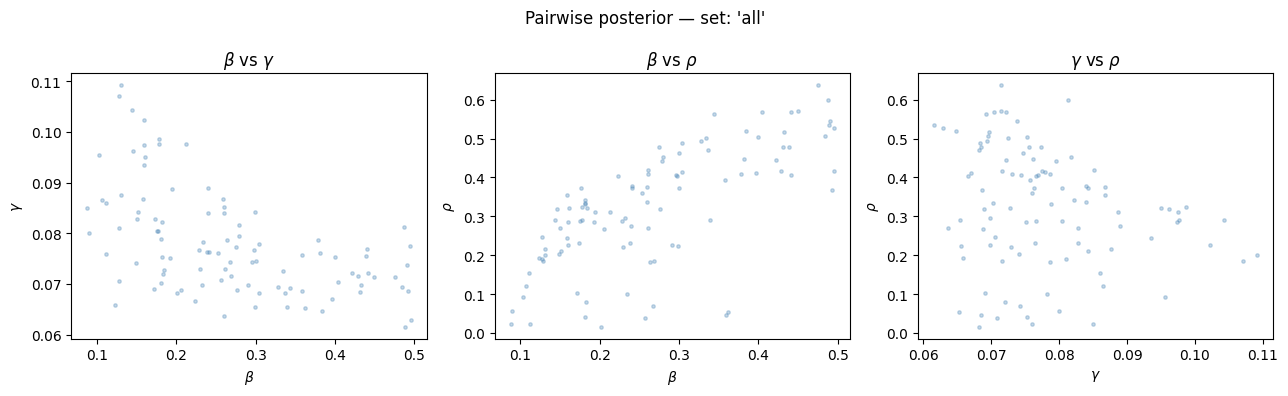

In [13]:
# ── Pairwise posterior scatter ────────────────────────────────────────────────
pairs = [(0, 1), (0, 2), (1, 2)]
pair_labels = [(r"$\beta$", r"$\gamma$"), (r"$\beta$", r"$\rho$"), (r"$\gamma$", r"$\rho$")]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (i, j), (xi, xj) in zip(axes, pairs, pair_labels):
    ax.scatter(accepted[:, i], accepted[:, j], s=6, alpha=0.3, color="steelblue", rasterized=True)
    ax.set(xlabel=xi, ylabel=xj, title=f"{xi} vs {xj}")
plt.suptitle(f"Pairwise posterior — set: '{ACTIVE_SET}'")
plt.tight_layout()

In [14]:
# ── Posterior summary ─────────────────────────────────────────────────────────
df = pd.DataFrame(accepted, columns=["beta", "gamma", "rho"])
display(df.describe().loc[["mean", "std", "25%", "50%", "75%"]].round(4))

,beta,gamma,rho
mean,0.2678,0.0779,0.3226
std,0.1150,0.0103,0.1523
25%,0.1760,0.0701,0.2239
50%,0.2581,0.0759,0.3226
75%,0.3474,0.0831,0.4253


## 6. Summary Set Comparison

Run ABC for every defined summary set and every tolerance level in one pass.  
All distances are pre-computed once per set, so this is cheap.

In [15]:
QUANTILES   = [0.005, 0.01, 0.02, 0.05, 0.10]   # tolerance levels to sweep
PARAM_NAMES = ["beta", "gamma", "rho"]
PRIOR_LOW   = np.array([0.05, 0.02, 0.0])
PRIOR_HIGH  = np.array([0.50, 0.20, 0.8])

def run_abc(feature_set: str, quantile: float):
    """Return accepted thetas and ε for one (set, quantile) combination."""
    s_sim = compute_summaries(sim_inf, sim_rew, sim_deg, feature_set=feature_set)
    s_obs = compute_summaries(obs_inf, obs_rew, obs_deg, feature_set=feature_set)
    scale = s_sim.std(axis=0).clip(min=1e-10)
    dists = np.linalg.norm((s_sim - s_obs) / scale, axis=1)
    eps   = np.quantile(dists, quantile)
    return thetas[dists <= eps], eps, dists

# ── Run all combinations ──────────────────────────────────────────────────────
# results[set_name][quantile] = (accepted_thetas, epsilon)
results = {}
for sname in SUMMARY_SETS:
    results[sname] = {}
    s_sim = compute_summaries(sim_inf, sim_rew, sim_deg, feature_set=sname)
    s_obs = compute_summaries(obs_inf, obs_rew, obs_deg, feature_set=sname)
    scale = s_sim.std(axis=0).clip(min=1e-10)
    dists = np.linalg.norm((s_sim - s_obs) / scale, axis=1)
    for q in QUANTILES:
        eps  = np.quantile(dists, q)
        acc  = thetas[dists <= eps]
        results[sname][q] = (acc, eps)

print("Done.  Sets:", list(SUMMARY_SETS.keys()))
print("Quantiles:", QUANTILES)

Done.  Sets: ['infection_only', 'infection_ts', 'rewiring_only', 'degree_only', 'all_scalar', 'all']
Quantiles: [0.005, 0.01, 0.02, 0.05, 0.1]


### 6a. Posterior width heatmap — which set is most informative per parameter?

Posterior std relative to the prior std.  Values near 0 = tight posterior (informative); near 1 = posterior ≈ prior (uninformative).

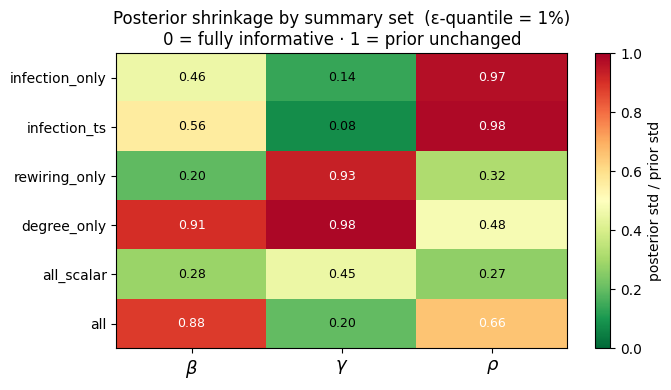

In [16]:
FIXED_Q = 0.01   # fix quantile for the set-comparison heatmap

prior_std = (PRIOR_HIGH - PRIOR_LOW) / np.sqrt(12)   # std of Uniform(a,b)

set_names = list(SUMMARY_SETS.keys())
# relative posterior std: shape (n_sets, 3)
rel_std = np.array([
    [results[s][FIXED_Q][0][:, j].std() / prior_std[j] for j in range(3)]
    for s in set_names
])

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(rel_std, vmin=0, vmax=1, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(3)); ax.set_xticklabels([r"$\beta$", r"$\gamma$", r"$\rho$"], fontsize=13)
ax.set_yticks(range(len(set_names))); ax.set_yticklabels(set_names)
for i in range(len(set_names)):
    for j in range(3):
        ax.text(j, i, f"{rel_std[i, j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if rel_std[i, j] > 0.6 else "black")
fig.colorbar(im, ax=ax, label="posterior std / prior std")
ax.set_title(f"Posterior shrinkage by summary set  (ε-quantile = {FIXED_Q:.0%})\n"
             "0 = fully informative · 1 = prior unchanged")
plt.tight_layout()

### 6b. Marginal posteriors — all summary sets overlaid

One column per parameter. Each coloured line is a different summary set at the same tolerance.

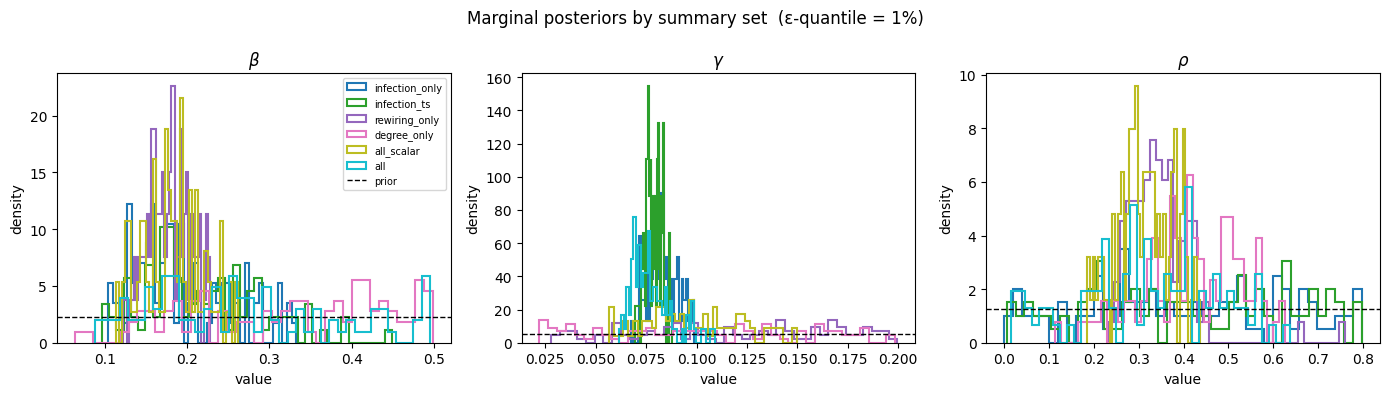

In [17]:
FIXED_Q   = 0.01
BINS      = 40
colors    = plt.cm.tab10(np.linspace(0, 1, len(set_names)))

param_labels = [r"$\beta$", r"$\gamma$", r"$\rho$"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, j, plabel in zip(axes, range(3), param_labels):
    for color, sname in zip(colors, set_names):
        acc = results[sname][FIXED_Q][0]
        ax.hist(acc[:, j], bins=BINS, density=True, histtype="step",
                linewidth=1.5, color=color, label=sname)
    ax.axhline(1 / (PRIOR_HIGH[j] - PRIOR_LOW[j]), color="black",
               ls="--", lw=1, label="prior")
    ax.set(title=plabel, xlabel="value", ylabel="density")

axes[0].legend(fontsize=7, loc="upper right")
fig.suptitle(f"Marginal posteriors by summary set  (ε-quantile = {FIXED_Q:.0%})")
plt.tight_layout()

### 6c. Tolerance sensitivity — how acceptance level affects the posterior

Fix the best-performing summary set and sweep over quantiles.  
Tighter tolerance = closer to the true posterior but fewer samples.

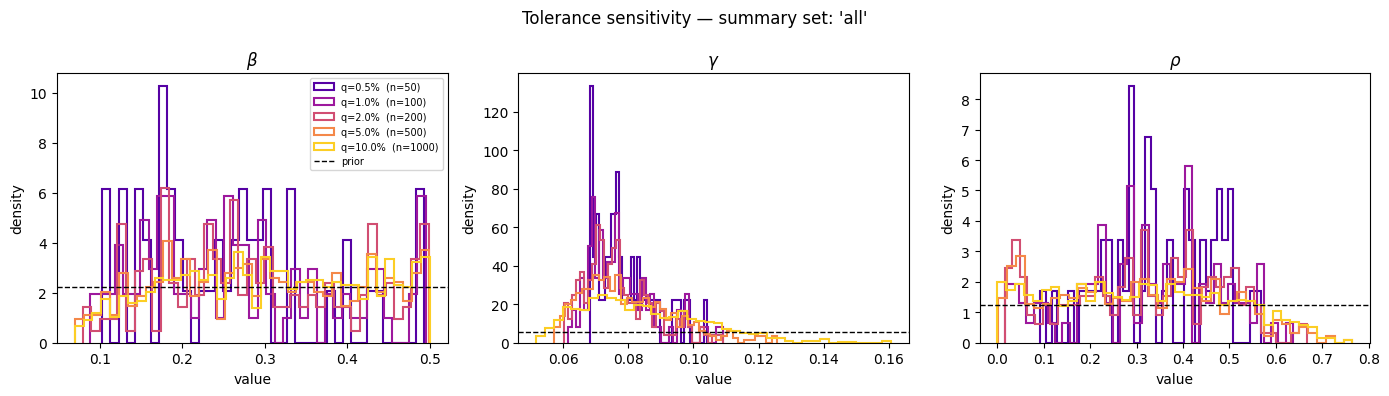

In [18]:
SWEEP_SET = "all"    # ← change to compare tolerance sensitivity for a different set

q_colors = plt.cm.plasma(np.linspace(0.15, 0.9, len(QUANTILES)))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, j, plabel in zip(axes, range(3), param_labels):
    for color, q in zip(q_colors, QUANTILES):
        acc, eps = results[SWEEP_SET][q]
        ax.hist(acc[:, j], bins=BINS, density=True, histtype="step",
                linewidth=1.5, color=color, label=f"q={q:.1%}  (n={len(acc)})")
    ax.axhline(1 / (PRIOR_HIGH[j] - PRIOR_LOW[j]), color="black",
               ls="--", lw=1, label="prior")
    ax.set(title=plabel, xlabel="value", ylabel="density")

axes[0].legend(fontsize=7)
fig.suptitle(f"Tolerance sensitivity — summary set: '{SWEEP_SET}'")
plt.tight_layout()

### 6d. Posterior std vs. tolerance — convergence curves

Shows how quickly each summary set's posterior tightens as tolerance decreases.  
Flat lines = the set has no more information to give; still-falling lines = tighter tolerance would help.

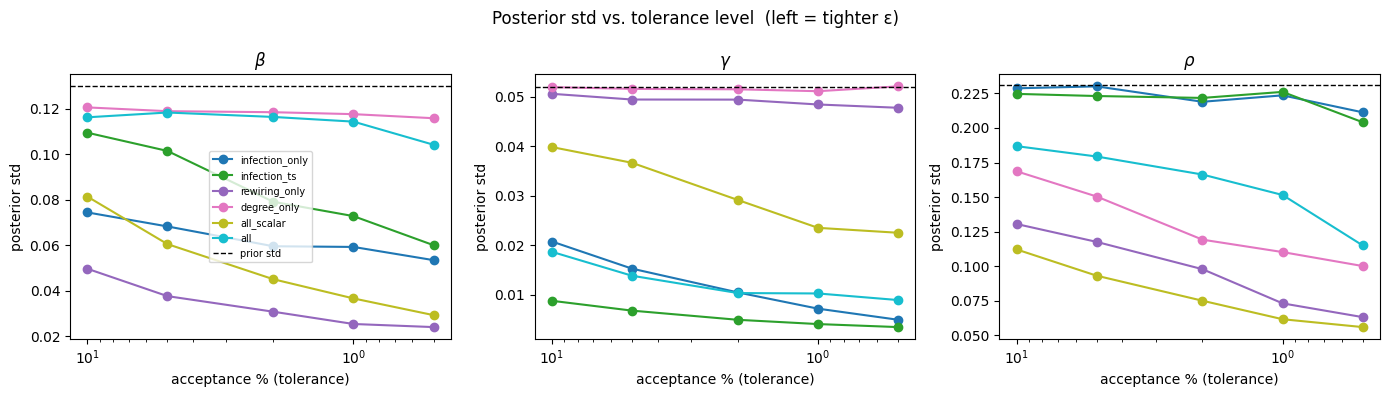

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, j, plabel in zip(axes, range(3), param_labels):
    for color, sname in zip(colors, set_names):
        stds = [results[sname][q][0][:, j].std() for q in QUANTILES]
        ax.plot([q * 100 for q in QUANTILES], stds,
                marker="o", color=color, label=sname)
    ax.axhline(prior_std[j], color="black", ls="--", lw=1, label="prior std")
    ax.set(title=plabel, xlabel="acceptance % (tolerance)", ylabel="posterior std",
           xscale="log")
    ax.invert_xaxis()   # tighter tolerance on the right

axes[0].legend(fontsize=7)
fig.suptitle("Posterior std vs. tolerance level  (left = tighter ε)")
plt.tight_layout()